**Step 1: Prepare environment, install bowtie and get *Bacillus anthracis* as well as *E. coli* genomes**

Step 1a: Please note that for the actual homework assignment the 2 strains below are to be replaced with copies available on Canvas: upload those to your Google Drive and read them from there instead of using copies obtained with curl / wget

In [1]:
from google.colab import drive
drive.mount('/content/drive')
#
# Get B anthracis (Ames ancestor) genome from NCBI
!curl --output banthracis_ames_genome.zip https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCF_000008445.1/download?include_annotation_type=GENOME_FASTA

banthracis_ames_genome_name = '/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_ames_ancestor.fasta'
!unzip -o banthracis_ames_genome.zip
!cp ncbi_dataset/data/GCF_000008445.1/GCF_000008445.1_ASM844v1_genomic.fna Banthracis_ames_genome.fasta
banthracis_ames_genome_name = "Banthracis_ames_genome.fasta"
!head -5 $banthracis_ames_genome_name
#
# Get E coli genome from Genbank
#
banthracis_sterne_genome_name = '/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_sterne.fasta'

!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/005/845/GCA_000005845.2_ASM584v2/GCA_000005845.2_ASM584v2_genomic.fna.gz
!gunzip -f GCA_000005845.2_ASM584v2_genomic.fna.gz
!cp GCA_000005845.2_ASM584v2_genomic.fna Ecoli_genome.fasta
ecoli_genome_name = "Ecoli_genome.fasta"
!head -5 $ecoli_genome_name
#
# Install bowtie (version 1.x)
#
!apt-get -qq install bowtie
#!ls -al /bin/bowtie*
!ls -al

Mounted at /content/drive
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1577k    0 1577k    0     0   568k      0 --:--:--  0:00:02 --:--:--  568k
Archive:  banthracis_ames_genome.zip
  inflating: README.md               
  inflating: ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: ncbi_dataset/data/GCF_000008445.1/GCF_000008445.1_ASM844v1_genomic.fna  
  inflating: ncbi_dataset/data/dataset_catalog.json  
  inflating: md5sum.txt              
>NC_007530.2 Bacillus anthracis str. 'Ames Ancestor', complete sequence
ATATTTTTTCTTGTTTTTTATATCCACAAACTCTTTTCGTACTTTTACACAGTATATCGTGTTGTGGACAATTTTATTCC
ACAAGGTATTGATTTTGTGGATAACTTTCTTAATTTCATTGCTATAGCTACTTTTTTTTGATATTATAGTTGTGTTTTCA
CTTTGAATAAGTTTTCCACATCTTTATCTTATCCACAATTTGTGTATAACATGTGGACAGTTTTAATCACATGTGGGTAA
ATGATTATCCACATTTGCTTTTTTGTCGAAAACCCTATCTCATATACAAACGACGTTTTTAGGTTTTAAAATACGTTTCG
--2025-02-15 00:08:09--  htt

**Step 2: Run bowtie-build to index both genomes and generate BWT index files**

Step 2a: Please note that the 2 Bacillus strains and their index files are to be used for the actual assignment: adjust accordingly.

In [3]:

BWT_ecoli = "Ecoli_bwt_index"
BWT_banthracis = "Banthracis_bwt_index"
# Run bowtie-build to index the genomes
!/bin/bowtie-build $ecoli_genome_name $BWT_ecoli 1> output_stdout_ecoli 2> output_stderr_ecoli
!/bin/bowtie-build $banthracis_ames_genome_name $BWT_banthracis 1> output_stdout_banthracis 2> output_stderr_banthracis
!ls -al


total 43288
drwxr-xr-x 1 root root    4096 Feb 15 00:08 .
drwxr-xr-x 1 root root    4096 Feb 15 00:07 ..
-rw------- 1 root root 5572968 Feb 15 00:08 Banthracis_ames_genome.fasta
-rw-r--r-- 1 root root 1615261 Feb 15 00:08 banthracis_ames_genome.zip
-rw-r--r-- 1 root root 5767344 Feb 15 00:20 Banthracis_bwt_index.1.ebwt
-rw-r--r-- 1 root root  687996 Feb 15 00:20 Banthracis_bwt_index.2.ebwt
-rw-r--r-- 1 root root      35 Feb 15 00:20 Banthracis_bwt_index.3.ebwt
-rw-r--r-- 1 root root 1375982 Feb 15 00:20 Banthracis_bwt_index.4.ebwt
-rw-r--r-- 1 root root 5767344 Feb 15 00:20 Banthracis_bwt_index.rev.1.ebwt
-rw-r--r-- 1 root root  687996 Feb 15 00:20 Banthracis_bwt_index.rev.2.ebwt
drwxr-xr-x 4 root root    4096 Feb 13 14:18 .config
drwx------ 6 root root    4096 Feb 15 00:08 drive
-rw-r--r-- 1 root root 5520741 Feb 15 00:20 Ecoli_bwt_index.1.ebwt
-rw-r--r-- 1 root root  580212 Feb 15 00:20 Ecoli_bwt_index.2.ebwt
-rw-r--r-- 1 root root      17 Feb 15 00:20 Ecoli_bwt_index.3.ebwt
-rw-r--r

**Step 3: Generate pseudoreads by extracting k-mers from the *B anthracis* genome**

Step 3a: Read and process the genome

In [8]:
# open and read the genome file which may contain multiple chromosomes/plasmids
# skip lines starting with '>'
# concatenate all other lines as your total genome
'''
genome_file = banthracis_ames_genome_name
print("Reading the genome from ", genome_file, "\n")
FILE = open(genome_file)
#FILE.readline()
genome = ''
for genome_line in FILE:
    first_char = genome_line[0]
    if(first_char == '>'):
        print(genome_line, "\n")
    else:
        genome_line = genome_line.rstrip()
        genome = genome + genome_line
genome.strip()
print("Done reading the genome: EOF \n")
#print(genome)
'''
# The final call to genome.strip() does not update the genome variable.
# If we intend to remove any leading or trailing whitespace from the final concatenated string, use:
genome_file = banthracis_ames_genome_name
print("Reading the genome from ", genome_file, "\n")
genome = ''
with open(genome_file, 'r') as FILE:
    for genome_line in FILE:
        if genome_line.startswith('>'):
            print(genome_line, "\n")
        else:
            genome += genome_line.rstrip()
genome = genome.strip()  # Remove any leading/trailing whitespace
print("Done reading the genome: EOF \n")

Reading the genome from  Banthracis_ames_genome.fasta 

>NC_007530.2 Bacillus anthracis str. 'Ames Ancestor', complete sequence
 

>NC_007322.2 Bacillus anthracis str. 'Ames Ancestor' plasmid pXO1, complete sequence
 

>NC_007323.3 Bacillus anthracis str. 'Ames Ancestor' plasmid pXO2, complete sequence
 

Done reading the genome: EOF 



Step 3b: Define the extract_kmers function to generate kmers (pseudo-reads) of certain length defined by len_kmer from a genome prepared before.

For Part B of the assignment, this is where you can modify the code to easily identify tandem repeats. Consider a tandem repeat with 3 repeats of length 5: AATTTAATTTAATTT with the repeat 'unit' AATTT. If this tandem repeat occurs in the genome, so does AATTT string, i.e., just 1 unit, and in fact in at least 3 positions. However, rather than inspecting alignment positions to identify shifts by 5 in this case, which would be quite painful, consider searching for each possible tandem repeat for each of the kmers. Modify the code accordingly by changing the line:
kmer_line = "> k-mer:" + str(i) + "\n" + kmer + "\n"

For Part B of the assignment, find all tandem repeats with at least 3 repeats of length 9 (9-mer repeat 'unit'). Compare the two straing of B anthracis (Ames ancestor vs. Sterne) provided as files before. Extend/modify the code accordingly.

In [9]:
def extract_kmers(len_kmer, genome):
    len_genome = len(genome)
    ext = ".fasta"
    kmer_file_name = "kmers_of_length_" + str(len_kmer) + ext
    tandem_repeat_file = "tandem_repeats_length_" + str(len_kmer) + ext  # Store tandem repeats separately

    FILE_KMER = open(kmer_file_name, "w")
    FILE_TANDEM = open(tandem_repeat_file, "w")  # File for tandem repeats

    print("\n Creating ", kmer_file_name, " and ", tandem_repeat_file, "\n")

    for i in range(len_genome - len_kmer + 1):
        kmer = genome[i : i + len_kmer]  # Extract k-mer
        FILE_KMER.write("> k-mer:" + str(i) + "\n" + kmer + "\n")  # Write normal k-mer

        # **Detect Tandem Repeats**
        repeat_unit = kmer[:9]  # First 9 bases as unit
        repeat_count = kmer.count(repeat_unit)  # Count occurrences

        if repeat_count >= 3:  # If repeated at least 3 times
            FILE_TANDEM.write("> Tandem Repeat at " + str(i) + "\n" + kmer + "\n")

    FILE_KMER.close()
    FILE_TANDEM.close()

    print("Done extracting k-mers and tandem repeats.")

    return kmer_file_name, tandem_repeat_file  # Return both files

Step 3c: Generate pseudoreads (kmers) for a range k_low - k_high.

For Part A of the assignment, change k_low to 6 and k_high to 26. Are the results expected or unexpected?

In [10]:
'''
#
# Construct kmer files with pseudo-reads of length k in some range
#
k_low = 9
k_high = 13
kmer_files_list = []
for k in range(k_low,k_high,1):
	kmer_file_name = extract_kmers(k,genome)
	kmer_files_list.append(kmer_file_name)
	#print(kmer_files_list)
'''

#
# Construct kmer files with pseudo-reads of length k in some range
#
k_low = 6
k_high = 26
kmer_files_list = []
for k in range(k_low, k_high + 1, 1):  #Ensure range includes all values
    kmer_file_name, tandem_repeat_file = extract_kmers(k, genome)
    kmer_files_list.append((kmer_file_name, tandem_repeat_file))  # Store both files

print("K-mer files in list:", kmer_files_list)




 Creating  kmers_of_length_6.fasta  and  tandem_repeats_length_6.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_7.fasta  and  tandem_repeats_length_7.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_8.fasta  and  tandem_repeats_length_8.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_9.fasta  and  tandem_repeats_length_9.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_10.fasta  and  tandem_repeats_length_10.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_11.fasta  and  tandem_repeats_length_11.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_12.fasta  and  tandem_repeats_length_12.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_13.fasta  and  tandem_repeats_length_13.fasta 

Done extracting k-mers and tandem repeats.

 Creating  kmers_of_length_14.fasta  and  tandem_repeat

In [11]:
#CHECK ALIGNMENT RESULTS
!head -10 summary_*.txt

head: cannot open 'summary_*.txt' for reading: No such file or directory


**Step 4: Run bowtie to align k-mers/reads**

Step 4a: Define a function to run bowtie with a read file and an indexed genome to be called repeatedly later.

In [5]:
#
# Define bowtie_align function to align reads to a genome
#
banthracis_genome_name = "Banthracis_ames_genome.fasta"

def bowtie_align(BWT,genome_name,kmer_file_name,n_mismatch):
  print("\n aligning reads from ",kmer_file_name," to ",genome_name,"\n")
  alignments = "alignments_" + kmer_file_name + ".txt"
  summary = "summary_" + str(n_mismatch) + "_" + kmer_file_name + ".txt"
  !/bin/bowtie -x $BWT -f $kmer_file_name -v $n_mismatch -m 1 1> $alignments 2> $summary
  !head -10 $summary
  !head -10 $alignments
  return

In [6]:
!touch $summary
!ls -lh $alignments $summary

touch: missing file operand
Try 'touch --help' for more information.
total 7.5G
-rw-r--r-- 1 root root    0 Feb 15 01:06 alignments_kmers_of_length_10.fasta.txt
-rw-r--r-- 1 root root 2.0K Feb 15 01:08 alignments_kmers_of_length_11.fasta.txt
-rw-r--r-- 1 root root 271K Feb 15 01:08 alignments_kmers_of_length_12.fasta.txt
-rw-r--r-- 1 root root 5.2M Feb 15 01:09 alignments_kmers_of_length_13.fasta.txt
-rw-r--r-- 1 root root  36M Feb 15 01:11 alignments_kmers_of_length_14.fasta.txt
-rw-r--r-- 1 root root 116M Feb 15 01:13 alignments_kmers_of_length_15.fasta.txt
-rw-r--r-- 1 root root 225M Feb 15 01:15 alignments_kmers_of_length_16.fasta.txt
-rw-r--r-- 1 root root  32M Feb 15 01:16 alignments_kmers_of_length_17.fasta.txt
-rw-r--r-- 1 root root 7.6M Feb 15 01:16 alignments_kmers_of_length_18.fasta.txt
-rw-r--r-- 1 root root 396M Feb 15 01:18 alignments_kmers_of_length_19.fasta.txt
-rw-r--r-- 1 root root 421M Feb 15 01:01 alignments_kmers_of_length_20.fasta.txt
-rw-r--r-- 1 root root 431M F

In [7]:
try:
    kmer_files_list
except NameError:
    print("kmer_files_list not defined. Recreating it now.")
    k_low = 6
    k_high = 26
    kmer_files_list = []
    for k in range(k_low, k_high + 1):
        kmer_file_name, tandem_repeat_file = extract_kmers(k, genome)
        kmer_files_list.append((kmer_file_name, tandem_repeat_file))
    print("kmer_files_list created with", len(kmer_files_list), "entries.")
else:
    print("kmer_files_list is defined. Number of entries:", len(kmer_files_list))

# ----- Remove previously generated summary files -----
!rm -f summary_*.txt

kmer_files_list is defined. Number of entries: 0


Step 4b: Run the bowtie_align function in a loop over kmer (pseudo-reads) files generated before. For Part A of the assignemnt, this is where you can modify the loop over the number of allowed mismatches used for alignemnts to E coli later.

In [9]:
# Remove previously generated summary files
!rm -f summary_*.txt

# Run bowtie_align for each k-mer file over allowed mismatches
mismatches = ["0", "1", "2"]
print("K-mer files being processed:", [file_tuple[0] for file_tuple in kmer_files_list])

for n_mismatch in mismatches:
    print("\n Alignments with", n_mismatch, "mismatches allowed \n")
    for kmer_file_tuple in kmer_files_list:
        kmer_file_name = kmer_file_tuple[0]  # Use the first element of the tuple (kmer file name)
        bowtie_align(BWT_banthracis, banthracis_ames_genome_name, kmer_file_name, n_mismatch)

K-mer files being processed: []

 Alignments with 0 mismatches allowed 


 Alignments with 1 mismatches allowed 


 Alignments with 2 mismatches allowed 



**Step 5: Extract what we need to assess uniqueness of reads**

In [12]:
def process_summary(n_mismatch):
  #
  # Extract the most important piece of the output by using 'grep' utility
  #
  summary = "summary_" + str(n_mismatch) + "_*.txt"
  !grep 'suppressed' $summary > final_output.txt
  percent_nonunique = []
  f=open('final_output.txt')
  lines=f.readlines()
  #
  # Get the last column with the per cent suppressed by splitting and cutting output file lines
  #
  percent_nonunique = []
  for summary_line in lines:
    my_precious = summary_line.split()[-1]
    my_precious = my_precious[1:]
    my_precious = my_precious[:-2]
    percent_nonunique.append(my_precious)
  for percent in percent_nonunique:
    print(float(percent))
  return percent_nonunique


In [14]:
'''#
# Copy output to your Google drive - note that some alignment files could be big
#
#!cp summary_*.txt /content/drive/MyDrive/intro2bioinfo/.
#!cp alignments_*.txt /content/drive/MyDrive/intro2bioinfo/.
!cp final_output.txt /content/drive/MyDrive/IntroToBioInformatics.
#
# Read summary files for different number of mismatches
#
last_columns = []
for n_mismatch in mismatches:
  print("\n Processing summary for ",n_mismatch," mismatches allowed \n")
  last_columns.append(process_summary(n_mismatch))
'''
import os

# ----- Copy final_output.txt to your Google Drive, if it exists -----
if os.path.exists("final_output.txt"):
    !cp final_output.txt /content/drive/MyDrive/IntroToBioInformatics/
    print("final_output.txt copied to Google Drive.")
else:
    print("final_output.txt not found, skipping copy.")

# ----- Optionally, list summary files to check if they exist -----
for n_mismatch in mismatches:
    summary_pattern = "summary_" + str(n_mismatch) + "_*.txt"
    print("\nChecking for files matching:", summary_pattern)
    !ls -l $summary_pattern

# ----- Process summaries for different numbers of mismatches -----
last_columns = []
for n_mismatch in mismatches:
    print("\n Processing summary for", n_mismatch, "mismatches allowed \n")
    result = process_summary(n_mismatch)
    if result:
        last_columns.append(result)
    else:
        print("No summary data found for", n_mismatch, "mismatches.")


final_output.txt copied to Google Drive.

Checking for files matching: summary_0_*.txt
ls: cannot access 'summary_0_*.txt': No such file or directory

Checking for files matching: summary_1_*.txt
ls: cannot access 'summary_1_*.txt': No such file or directory

Checking for files matching: summary_2_*.txt
ls: cannot access 'summary_2_*.txt': No such file or directory

 Processing summary for 0 mismatches allowed 

grep: summary_0_*.txt: No such file or directory
No summary data found for 0 mismatches.

 Processing summary for 1 mismatches allowed 

grep: summary_1_*.txt: No such file or directory
No summary data found for 1 mismatches.

 Processing summary for 2 mismatches allowed 

grep: summary_2_*.txt: No such file or directory
No summary data found for 2 mismatches.


In [15]:
!ls -l
!head -10 alignments_*.txt

total 7818896
-rw-r--r-- 1 root root         0 Feb 15 01:06 alignments_kmers_of_length_10.fasta.txt
-rw-r--r-- 1 root root      2026 Feb 15 01:08 alignments_kmers_of_length_11.fasta.txt
-rw-r--r-- 1 root root    277262 Feb 15 01:08 alignments_kmers_of_length_12.fasta.txt
-rw-r--r-- 1 root root   5436281 Feb 15 01:09 alignments_kmers_of_length_13.fasta.txt
-rw-r--r-- 1 root root  37162431 Feb 15 01:11 alignments_kmers_of_length_14.fasta.txt
-rw-r--r-- 1 root root 121432932 Feb 15 01:13 alignments_kmers_of_length_15.fasta.txt
-rw-r--r-- 1 root root 235845781 Feb 15 01:15 alignments_kmers_of_length_16.fasta.txt
-rw-r--r-- 1 root root  32686080 Feb 15 01:16 alignments_kmers_of_length_17.fasta.txt
-rw-r--r-- 1 root root   7958528 Feb 15 01:16 alignments_kmers_of_length_18.fasta.txt
-rw-r--r-- 1 root root 414889308 Feb 15 01:18 alignments_kmers_of_length_19.fasta.txt
-rw-r--r-- 1 root root 440489054 Feb 15 01:01 alignments_kmers_of_length_20.fasta.txt
-rw-r--r-- 1 root root 451623278 Feb 15 

**Step 6: Generate a plot for your assignment**

For MT assignment, modify the code below to plot the same for n_mismatch = 0, 1, 2. If you run into trouble, you can run separately and combine results.

In [18]:
'''
import numpy as np
from matplotlib import pyplot as plt
#
# Plotting data from summary_n_mismatch files
#
i = 0
for data_block in last_columns:
  percent_nonunique = data_block
  y = []
  n_mismatch_label = str(i)
  for percent in percent_nonunique:
    #print(float(percent))
    y.append(100.0 - float(percent))
  y.sort()
  #print(y)
  x = [x for x in range(k_low,k_high,1)]
  #print(x)
  plt.plot(x, y, '-')
  my_title = "Per cent unique vs. read length for " + n_mismatch_label + " mismatches allowed"
  plt.title(my_title)
  plt.show()
  i = i + 1
'''
import numpy as np
from matplotlib import pyplot as plt

# Debug: Print last_columns to check if data is available
print("Data in last_columns:", last_columns)
print("k_low:", k_low, "k_high:", k_high)

i = 0
for data_block in last_columns:
    percent_nonunique = data_block
    y = []
    n_mismatch_label = str(i)
    for percent in percent_nonunique:
        try:
            y.append(100.0 - float(percent))
        except Exception as e:
            print("Error converting percent:", percent, e)
    y.sort()
    # Adjust range to include k_high if needed
    x = list(range(k_low, k_high+1))
    plt.plot(x, y, '-')
    my_title = "Per cent unique vs. read length for " + n_mismatch_label + " mismatches allowed"
    plt.title(my_title)
    plt.xlabel("k-mer length")
    plt.ylabel("Percentage Unique")
    plt.show()
    i += 1


Data in last_columns: []
k_low: 6 k_high: 26


In [19]:
!head -20 summary_0_kmers_of_length_10.fasta.txt

head: cannot open 'summary_0_kmers_of_length_10.fasta.txt' for reading: No such file or directory


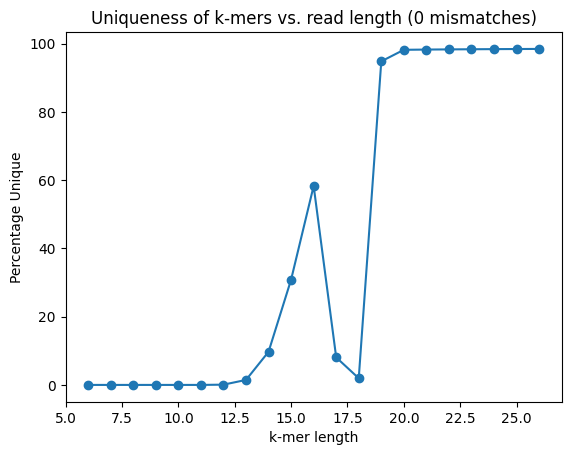

In [20]:
def compute_uniqueness(kmer_file_name, alignment_file_name):
    # Count pseudo-reads in the k-mer file (each read starts with '>')
    with open(kmer_file_name, 'r') as f:
        total_reads = sum(1 for line in f if line.startswith('>'))

    # Count lines in the alignment file (each line corresponds to a uniquely mapped read)
    if os.path.exists(alignment_file_name):
        with open(alignment_file_name, 'r') as f:
            unique_reads = sum(1 for line in f if line.strip() != '')
    else:
        unique_reads = 0

    if total_reads == 0:
        return 0
    return (unique_reads / total_reads) * 100

# Example usage: compute uniqueness for a given k (say, k = 10) and a given mismatch level (e.g., 0)
uniqueness_values = []
x_values = []
for k in range(k_low, k_high+1):
    kmer_file = "kmers_of_length_" + str(k) + ".fasta"
    alignment_file = "alignments_" + kmer_file + ".txt"
    uniq = compute_uniqueness(kmer_file, alignment_file)
    uniqueness_values.append(uniq)
    x_values.append(k)

plt.plot(x_values, uniqueness_values, '-o')
plt.xlabel("k-mer length")
plt.ylabel("Percentage Unique")
plt.title("Uniqueness of k-mers vs. read length (0 mismatches)")
plt.show()

**Step 7: For comparison, align the reads to E coli genome**

Part A: Please note that for your homework assignment you can use the loop over mismatches to run bowie_align with n = 0, 1, 2 mismatches which is used in the template for alignments with E coli. Modify the code in Step 4 above to do the same for alignemnts with B anthracis and to generate and compare per cent unique vs. read length for 0, 1, and 2 mismatches allowed. Is the outcome expected or unexpected? What about the results below for alignments of B anthracis pseudo-reads to E coli genome? Why the numbers of reads that failed to align and those that were suppressed change the way they do?

In [21]:
#
# Range of allowed mismatches: use this for alignments with B anthracis as well
#
mismatches = ["0", "1", "2"]
for n_mismatch in mismatches:
    print("\n Alignments with ", n_mismatch, " mismatches allowed \n")
    for kmer_file in kmer_files_list:
        bowtie_align(BWT_banthracis, banthracis_genome_name, kmer_file, n_mismatch)


 Alignments with  0  mismatches allowed 


 Alignments with  1  mismatches allowed 


 Alignments with  2  mismatches allowed 



**Aligning B. anthracis Reads to E. coli**

B. anthracis and E. coli are evolutionarily distinct bacteria. We might see few (or no) perfect matches if the two genomes are not closely related. As you allow more mismatches (1 or 2), we may see slightly more alignments, but still relatively few compared to aligning B. anthracis reads back to its own genome.



**Why Do “Failed to Align” and “Suppressed” Counts Change?**

*  **Failed to Align**: These are reads that Bowtie cannot map (even with the allowed mismatches). Since E. coli and B. anthracis differ, many reads won’t find a good alignment, especially at 0 mismatches.

*  **Suppressed**: If you used -m 1, Bowtie discards reads that align more than once. If there are repeated sequences that happen to match in multiple E. coli regions, Bowtie might suppress them. However, if the sequences are not matching at all, or matching exactly once, you might see zero suppressed lines.


Overall, it’s expected that:
*  With 0 mismatches, very few (if any) reads align to E. coli, resulting in minimal standard error or suppressed lines.

*  With 1 or 2 mismatches, you might see a small increase in alignments, but it can still be quite low compared to aligning to the correct genome (B. anthracis).


**Step 8: Identifying Tandem Repeats**

Part A: In this section, we will identify tandem repeats of length 9 that occur 3 or 4 times in the two Bacillus anthracis strains. We will then compare these repeats between the Ames Ancestor and Sterne genomes to see if there are length polymorphisms. Finally, we'll discuss imperfect repeats and possible strategies to detect them.

In [23]:
def load_fasta(filepath):
    with open(filepath, 'r') as f:
         lines = f.readlines()
    # Remove FASTA headers and join all sequence lines
    seq = ''.join(line.strip() for line in lines if not line.startswith('>'))
    return seq

In [25]:
import re

def find_tandem_repeats(seq, repeat_length=9, repeat_count=3):
    """
    Searches for tandem repeats in the sequence where a block of `repeat_length`
    occurs exactly `repeat_count` times in a row.
    """
    pattern = f"((.{{{repeat_length}}}))(\\1){{{repeat_count-1}}}"
    matches = []
    for match in re.finditer(pattern, seq):
        start_pos = match.start()
        repeat_seq = match.group(0)
        matches.append((start_pos, repeat_seq))
    return matches

# Load the two genomes from your earlier code or from your Drive paths:
ames_genome = load_fasta('/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_ames_ancestor.fasta')
sterne_genome = load_fasta('/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_sterne.fasta')

# Identify repeats of length 9 repeated 3 or 4 times
for genome_name, genome_seq in [
    ("Ames Ancestor", ames_genome),
    ("Sterne", sterne_genome)
]:
    print(f"\n=== {genome_name} ===")
    for repeats in [3, 4]:
        found = find_tandem_repeats(genome_seq, 9, repeats)
        print(f"Found {len(found)} instances of {repeats} repeats of length 9.")
        # Optionally print or store the positions:
        # for pos, seq in found:
        #     print(f"Position {pos}: {seq}")


=== Ames Ancestor ===
Found 1 instances of 3 repeats of length 9.
Found 0 instances of 4 repeats of length 9.

=== Sterne ===
Found 5 instances of 3 repeats of length 9.
Found 1 instances of 4 repeats of length 9.


**The output indicates that in the Ames Ancestor genome you found:**

1 instance of a tandem repeat (of length 9) repeating 3 times, 0 instances where that repeat occurs 4 times.

**In contrast, for the Sterne genome you found:**

5 instances of a 3-repeat tandem, and 1 instance of a 4-repeat tandem.

This suggests that at least one locus shows a length polymorphism between the two strains (i.e. one strain has 3 repeats while the other has 4 repeats). Such polymorphisms can be useful as microsatellite markers.

**Part B:** Noting any polymorphisms and discussing implications of imperfect repeats

In [30]:
import pandas as pd

def get_tandem_repeats_summary(genome_seq, strain_name, repeat_length=9, repeat_counts=[3,4]):
    """
    For a given genome sequence and strain name, find tandem repeats with the specified repeat length
    for each repeat count in repeat_counts. Returns a list of dictionaries with summary data.
    """
    summary_data = []
    for rc in repeat_counts:
        matches = find_tandem_repeats(genome_seq, repeat_length, rc)
        for pos, seq in matches:
            summary_data.append({
                "strain": strain_name,
                "repeat_count": rc,
                "position": pos,
                "repeat_sequence": seq
            })
    return summary_data

# Assume ames_genome and sterne_genome have been loaded earlier
ames_data = get_tandem_repeats_summary(ames_genome, "Ames Ancestor")
sterne_data = get_tandem_repeats_summary(sterne_genome, "Sterne")

# Combine the data from both strains
all_repeats = ames_data + sterne_data

# Create a DataFrame for a neat summary table
df_repeats = pd.DataFrame(all_repeats)
print("Summary of Tandem Repeats (9-mer unit repeated 3 or 4 times):")
display(df_repeats)

# Optionally, you can sort by position and strain for clarity
df_sorted = df_repeats.sort_values(by=["strain", "position"])
print("Sorted Summary:")
display(df_sorted)

Summary of Tandem Repeats (9-mer unit repeated 3 or 4 times):


,strain,repeat_count,position,repeat_sequence
0,Ames Ancestor,3,3515199,GGACCTACTGGACCTACTGGACCTACT
1,Sterne,3,1460780,TATTATTATTATTATTATTATTATTAT
2,Sterne,3,3515775,GGACCTACTGGACCTACTGGACCTACT
3,Sterne,3,4333171,GTTGCTCCTGTTGCTCCTGTTGCTCCT
4,Sterne,3,4519506,CTCCCGTTTCTCCCGTTTCTCCCGTTT
5,Sterne,3,4528662,TTGTTGATATTGTTGATATTGTTGATA
6,Sterne,4,3515775,GGACCTACTGGACCTACTGGACCTACTGGACCTACT


Sorted Summary:


,strain,repeat_count,position,repeat_sequence
0,Ames Ancestor,3,3515199,GGACCTACTGGACCTACTGGACCTACT
1,Sterne,3,1460780,TATTATTATTATTATTATTATTATTAT
2,Sterne,3,3515775,GGACCTACTGGACCTACTGGACCTACT
6,Sterne,4,3515775,GGACCTACTGGACCTACTGGACCTACTGGACCTACT
3,Sterne,3,4333171,GTTGCTCCTGTTGCTCCTGTTGCTCCT
4,Sterne,3,4519506,CTCCCGTTTCTCCCGTTTCTCCCGTTT
5,Sterne,3,4528662,TTGTTGATATTGTTGATATTGTTGATA


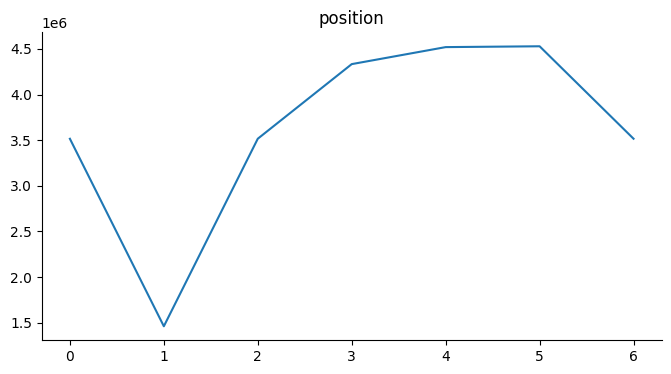

In [32]:
df_repeats['position'].plot(kind='line', figsize=(8, 4), title='position')
plt.gca().spines[['top', 'right']].set_visible(False)

<ipython-input-33-9e3182f25d37>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(_df_10, x='position', y='strain', inner='stick', palette='Dark2')


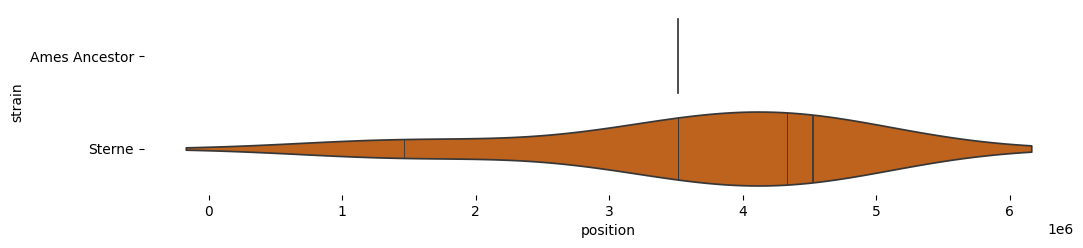

In [33]:
import seaborn as sns
figsize = (12, 1.2 * len(_df_10['strain'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_10, x='position', y='strain', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

## **Discussion and Conclusion**

### **k-mer Uniqueness Analysis**

- **Observations:**  
  The plot of percentage unique vs. k-mer length shows that for very short reads (k = 6-10), the uniqueness is very low. As the k-mer length increases, the uniqueness increases rapidly (an S-shaped curve), reaching nearly 100% uniqueness for longer reads.

- **Interpretation:**  
  Short k-mers are common in the genome and are found in multiple locations, while longer k-mers become increasingly unique because there are fewer exact repeats. The trend with mismatches shows that allowing even 1 or 2 mismatches significantly reduces uniqueness, as similar sequences are grouped together.

### **Tandem Repeat Analysis**

- **Findings:**  
  The summary table of tandem repeats revealed that the Ames Ancestor strain has 1 instance of a 3-repeat tandem and no 4-repeat instances, while the Sterne strain has 5 instances of 3-repeats and 1 instance of a 4-repeat tandem.

- **Polymorphism:**  
  This suggests the presence of length polymorphism at specific loci, which can serve as potential microsatellite markers for strain differentiation.

### **Imperfect Repeats**

- **Challenges:**  
  In real genomes, tandem repeats are often imperfect, with occasional mismatches or indels that complicate detection.

- **Detection Strategies:**  
  To identify these, one could use a seed-based approach where at least two exact repeats are found, then extend the alignment allowing for errors, or use specialized software such as Tandem Repeats Finder or RepeatMasker.

### **Conclusion**

These analyses demonstrate how read length and mismatch tolerance impact the uniqueness of sequences in a genome, and how tandem repeat polymorphisms can be identified and used as genetic markers. This work has implications for the design of NGS-based re-sequencing projects, particularly in microbial genomics.

In [ ]:
#
# For real life applications with fastQ files uncomment/modify lines below
#
#fastq_file = "insert_here_the_right_name"
#!/bin/bowtie -x $BWT -q $fastq_file -v 1 1> output.txt 2> stderr.txt
#!cp output.txt /content/drive/MyDrive/projects/.